In [1]:
import random
import math
import numpy as np
import matplotlib.pyplot as plt

random.seed(42)  

# Coupling Class for both Complex and Power Coupling

## Complex Coupled Oscillator Equations

$\dot{r_1} = (\mu - r_1^2)r_1 + A r_2 \cos(\theta_2 - \theta_1 + \phi)
$ <br>
$\dot{\theta}_1 = \omega_1 + A \frac{r_2}{r_1} \sin(\theta_2 - \theta_1 + \phi)
$ <br><br>And for the second oscillator, $z_2$: <br>
$\dot{r_2} = (\mu - r_2^2)r_2 + A r_1 \cos(\theta_1 - \theta_2 - \phi)
$ <br>
$\dot{\theta}_2 = \omega_2 + A \frac{r_1}{r_2} \sin(\theta_1 - \theta_2 - \phi)
$ <br><br>


## Power Coupled Oscillator Equations

$\dot{r_1} = (\mu - r_1^2)r_1 + A_{12}  r_2^{\frac{\omega_1}{\omega_2}} \cos \left( \omega_1\left( \frac{\theta_2}{\omega_2} - \frac{\theta_1}{\omega_1} + \frac{\phi_{12}}{\omega_1 \omega_2} \right) \right)
$ <br>
$\dot{\theta}_1 = \omega_1 + A_{12} \frac{r_2^{\frac{\omega_1}{\omega_2}}}{r_1} \sin \left( \omega_1 \left( \frac{\theta_2}{\omega_2} - \frac{\theta_1}{\omega_1} + \frac{\phi_{12}}{\omega_1 \omega_2} \right) \right)
$<br><br>And for the second oscillator, $z_2$: <br>
$\dot{r_2} = (\mu - r_2^2)r_2 + A_{21}  r_2^{\frac{\omega_2}{\omega_1}} \cos \left( \omega_2\left( \frac{\theta_1}{\omega_1} - \frac{\theta_2}{\omega_2} + \frac{\phi_{21}}{\omega_1 \omega_2} \right) \right)
$ <br>
$\dot{\theta}_2 = \omega_2 + A_{21} \frac{r_1^{\frac{\omega_2}{\omega_1}}}{r_2} \sin \left( \omega_2 \left( \frac{\theta_1}{\omega_1} - \frac{\theta_2}{\omega_2} + \frac{\phi_{21}}{\omega_1 \omega_2} \right) \right)
$

In [2]:
class Coupling_Class():
    def __init__(self, coupling_type, w1, w2, phi, mu = None, r1 = None, r2 = None, theta1 = None, theta2 = None, A = None, dt = 0.1, iter = 10_000):
        self.coupling_type = coupling_type

        #Parameters that are given by the question:
        self.w1 = w1
        self.w2 = w2
        self.phi = phi #Assuming that phi12 = phi = -phi21

        # Other paramers that can be either user defined or randomly initialized if not provided:
        self.mu = random.randint(1,10) if mu == None else mu 
        self.r1 = random.uniform(0.6, 0.8) if r1 == None else r1
        self.r2 = random.uniform(0.6, 0.8) if r2 == None else r2
        self.theta1 = random.uniform( -180, 180) if theta1 == None else theta1
        self.theta2 = random.uniform(-180, 180) if theta2 == None else theta2

        # self.r1 = 0.8  
        # self.theta1 = 0.1 
        # self.r2 = 0.5
        # self.theta2 = -0.2
        self.A = 0.2 if A == None else A #Assuming A21 = A12 = A. This low value for A ensures that the parameters don't reach 0 immediately.

        self.dt = dt #Time step variable
        self.iter = iter #Number of iterations, total time = iter * dt

        self.r1_hist, self.r2_hist, self.theta1_hist,self.theta2_hist = [], [], [], []
        

    def forward_integration(self):
        mu = self.mu
        A = self.A
        phi = self.phi
        w1 = self.w1
        w2 = self.w2

        dt = self.dt
        iter = self.iter

        #forward euler integration method, to calculate the parameter values over time:
        for i in range(iter):
            if self.coupling_type == 'Complex':
                dr1 = (mu - (self.r1)**2) * self.r1 + A * self.r2 * np.cos(math.radians(self.theta2 - self.theta1 + phi))
                dtheta1 = w1 + A * (self.r2/self.r1) * np.sin(math.radians(self.theta2 - self.theta1 + phi))

                dr2 = (mu - (self.r2)**2) * self.r2 + A * self.r1 * np.cos(math.radians(self.theta1 - self.theta2 - phi))
                dtheta2 = w2 + A * (self.r1/self.r2) * np.sin(math.radians(self.theta1 - self.theta2 - phi))

            elif self.coupling_type == 'Power':
                dr1 = (mu - (self.r1)**2) * self.r1 + (A * (self.r2)**(w1/w2)) * np.cos(w1 * math.radians((self.theta2/w2 - self.theta1/w1 + (phi/(w1*w2)))))
                dtheta1 = w1 + (A * ((self.r2)**(w1/w2))/self.r1) * np.sin(w1 * math.radians((self.theta2/w2 - self.theta1/w1 + (phi/(w1*w2)))))

                dr2 = (mu - (self.r2)**2) * self.r2 + (A * (self.r1)**(w2/w1)) * np.cos(w2 * math.radians((self.theta1/w1 - self.theta2/w2 - (phi/(w1*w2)))))
                dtheta2 = w2 + (A * ((self.r1)**(w2/w1))/self.r2) * np.sin(w2 * math.radians((self.theta1/w1 - self.theta2/w2 - (phi/(w1*w2)))))

            #Update and store vars 
            self.r1 += dr1 * dt
            self.theta1 += dtheta1 * dt

            self.r2 += dr2 * dt
            self.theta2 += dtheta2 * dt

            self.r1_hist.append(self.r1)
            self.r2_hist.append(self.r2)
            self.theta1_hist.append(self.theta1)
            self.theta2_hist.append(self.theta2)

        return self.r1_hist, self.r2_hist, self.theta1_hist, self.theta2_hist

#Plotter Functions

In [3]:
def response_plotter(w1, w2, phi, coupling_type):
    # run model 
    model = Coupling_Class(coupling_type, w1, w2, phi)
    r1_hist, r2_hist, theta1_hist, theta2_hist = model.forward_integration()

    #Since we have to plot the real part of the oscillator's complex state z, we use real(z) = real(r(costheta + isintheta)) = rcostheta
    z1_real_values = r1_hist * np.cos(np.radians(theta1_hist))
    z2_real_values = r2_hist * np.cos(np.radians(theta2_hist))

    # create time for plot
    t = list(np.linspace(0, 10_000, 10_000))

    plt.figure(figsize=(16, 6))
    plt.title(f"Oscillator Response for {coupling_type} Coupling with w1 = {w1}, w2 = {w2}, phi = {phi}°")
    plt.plot(t, z1_real_values)
    plt.plot(t, z2_real_values)

    plt.legend(['Oscillator 1', 'Oscillator 2'])
    plt.ylabel("real(z)")
    plt.xlabel("Time (0.1 s)")  # I'm using dt -1e-1
    plt.show()

This second plotter function plots the phase difference (in the case of complex coupling) or normalized phase difference (for power coupling) between the two coupled oscillators over time. To show that these values converge to a constant in both complex (where it converges to φ) and power (where it converges to φ/ω1ω2) coupling at steady state irrespective of the starting point, I've plotted several trials each of which have different, random starting points for the other parameters. That constant value is demarcated by a horizontal dashed line.

In [4]:
def phase_diff_plotter(w1, w2, phi, coupling_type):
    colors = ['violet', 'thistle', 'indigo', 'fuchsia', 'deeppink'] * 2
    for trial in range(10):
        model = Coupling_Class(coupling_type, w1, w2, phi)
        r1_hist, r2_hist, theta1_hist, theta2_hist = model.forward_integration()

        if coupling_type == 'Complex':
            ψ = np.subtract(theta1_hist, theta2_hist) #This is the phase difference between the oscillators.
        elif coupling_type == 'Power':
            ψ = np.subtract([theta1/w1 for theta1 in theta1_hist], [theta2/w2 for theta2 in theta2_hist]) #This is the normalized phase difference between the oscillators.

        t = list(np.linspace(0, 10000, 10000))
        plt.plot(t, ψ, color = colors[trial])

    SS_value = phi if coupling_type == 'Complex' else phi/(w1 * w2)
    plt.axhline(SS_value, linestyle="dashed") #To mark the value which ψ will converge to at steady state.
    plt.title(f"{'Normalized ' if coupling_type == 'Power' else ''}Phase Difference between Oscillators for {coupling_type} Coupling with w1 = {w1}, w2 = {w2}, phi = {phi}°")
    plt.ylabel(f"{'Normalized ' if coupling_type == 'Power' else ''}Phase Difference (in degrees)")
    plt.xlabel("Time (0.1 s)")
    plt.ylim(SS_value - 5, SS_value + 5)
    plt.figure(figsize=(10, 6))
    plt.show()

#Complex Coupling

Given parameters:

In [5]:
w1 = w2 = 5
phi1 = -47
phi2 = 98

##Complex coupling with a phase difference of -47 degrees:

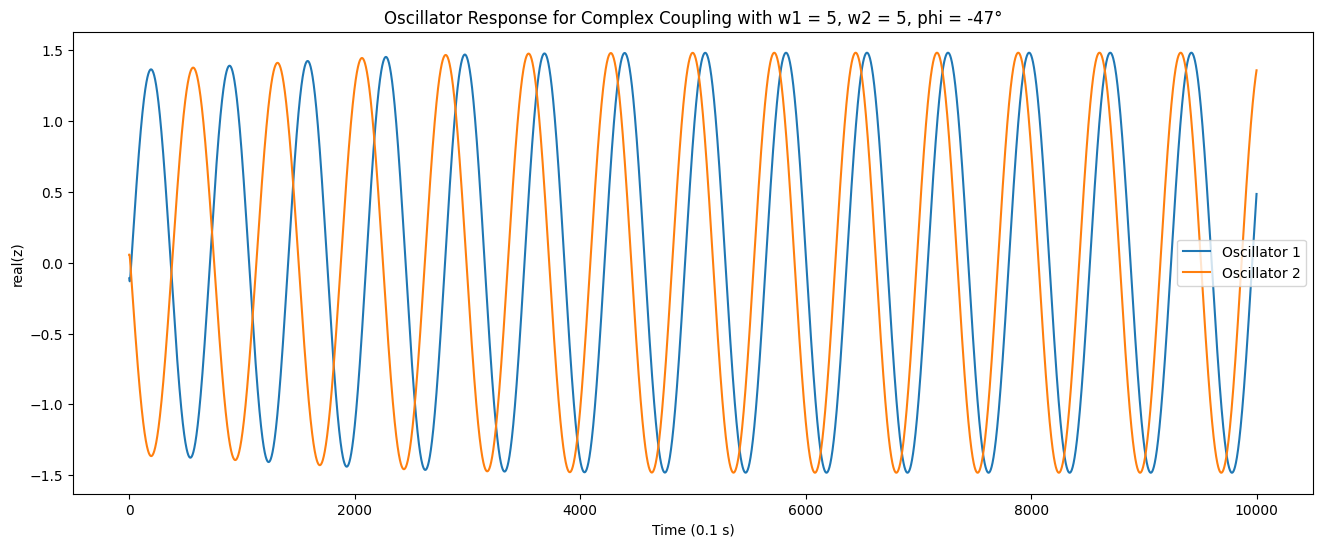

In [6]:
response_plotter(w1, w2, phi1, 'Complex')

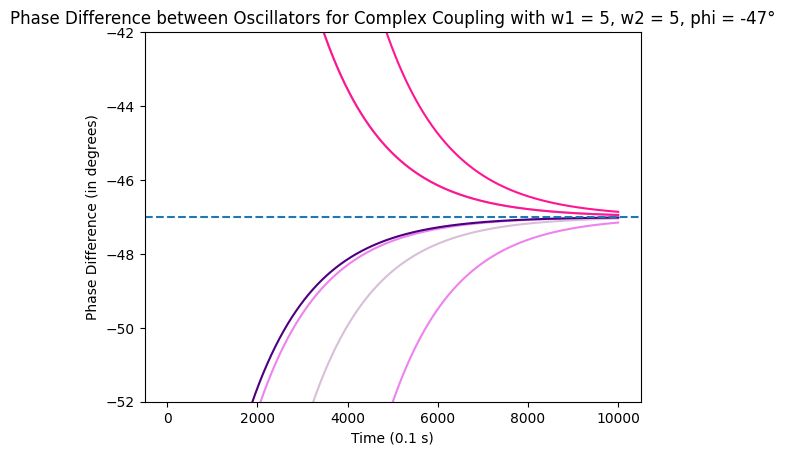

<Figure size 1000x600 with 0 Axes>

In [7]:
phase_diff_plotter(w1, w2, phi1, 'Complex')

##Complex coupling with a phase difference of 98 degrees:

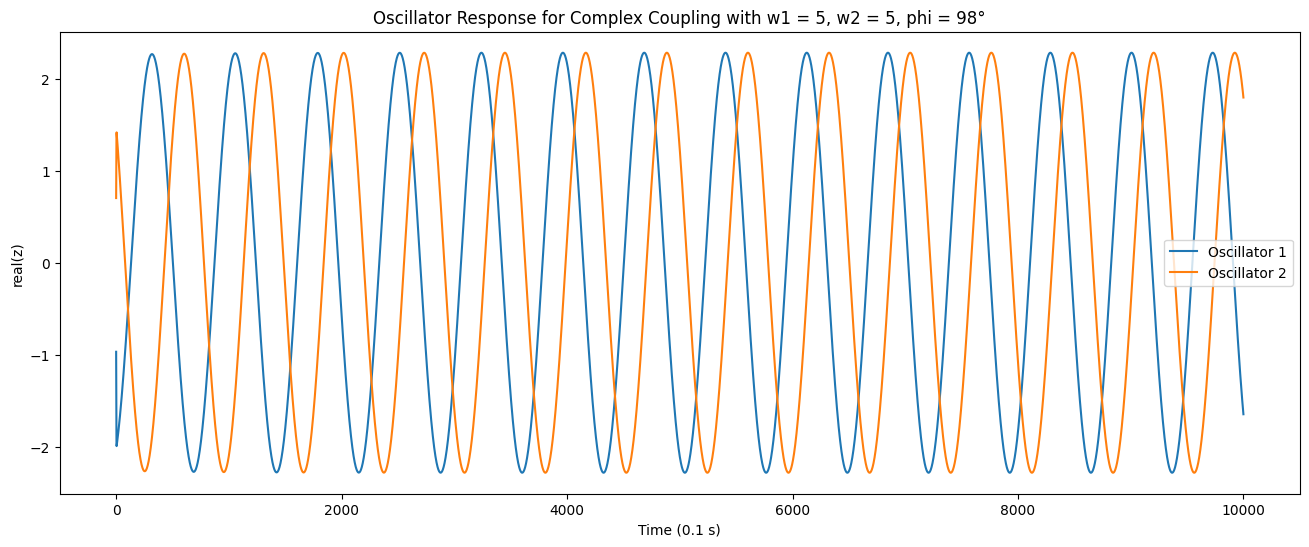

In [8]:
response_plotter(w1, w2, phi2, 'Complex')

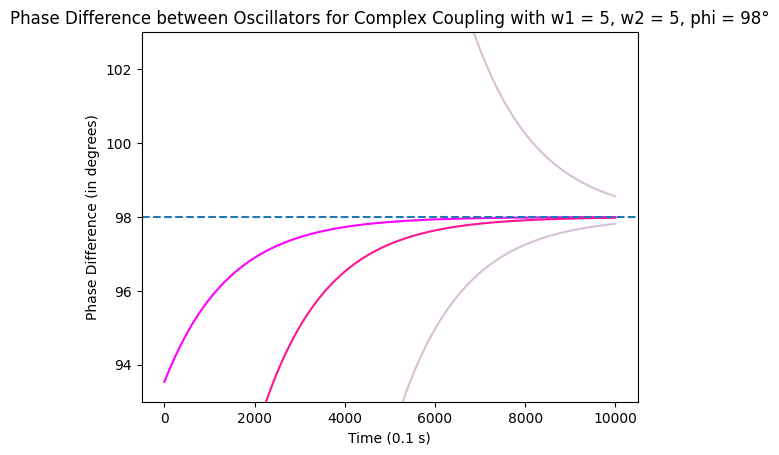

<Figure size 1000x600 with 0 Axes>

In [9]:
phase_diff_plotter(w1, w2, phi2, 'Complex')

#Power Coupling

Given parameters:

In [10]:
w1 = 5
w2 = 15
phi1 = -47
phi2 = 98

##Power coupling with a phase difference of -47 degrees:

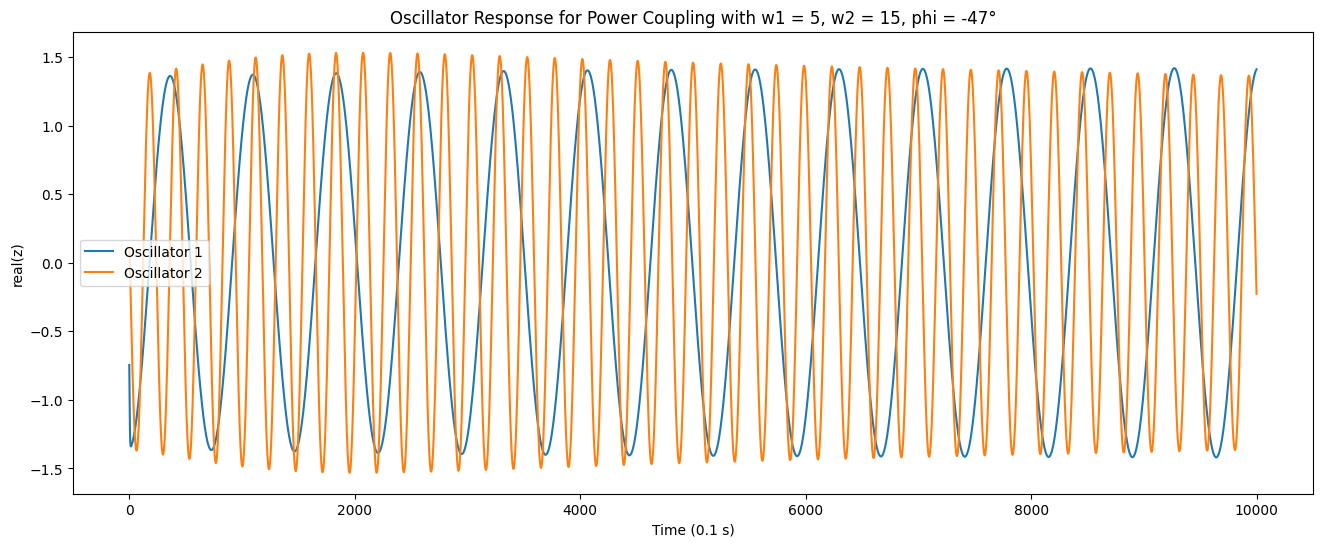

In [11]:
response_plotter(w1, w2, phi1, 'Power')

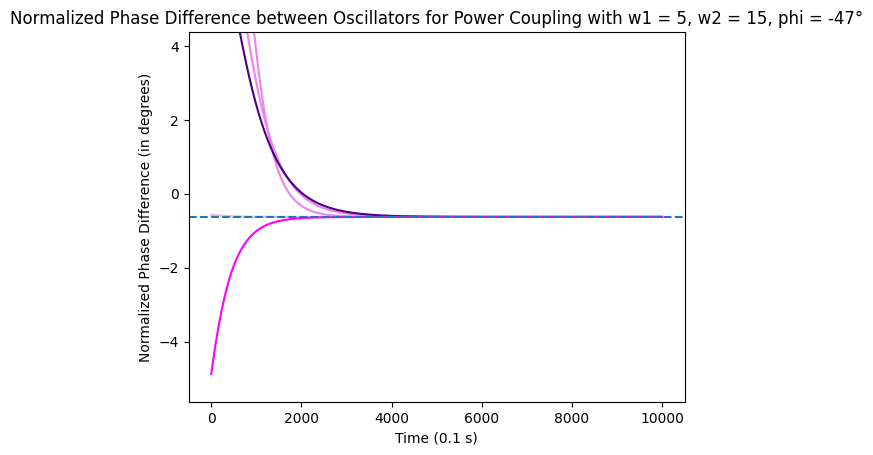

<Figure size 1000x600 with 0 Axes>

In [12]:
phase_diff_plotter(w1, w2, phi1, 'Power')

##Power coupling with a phase difference of 98 degrees:

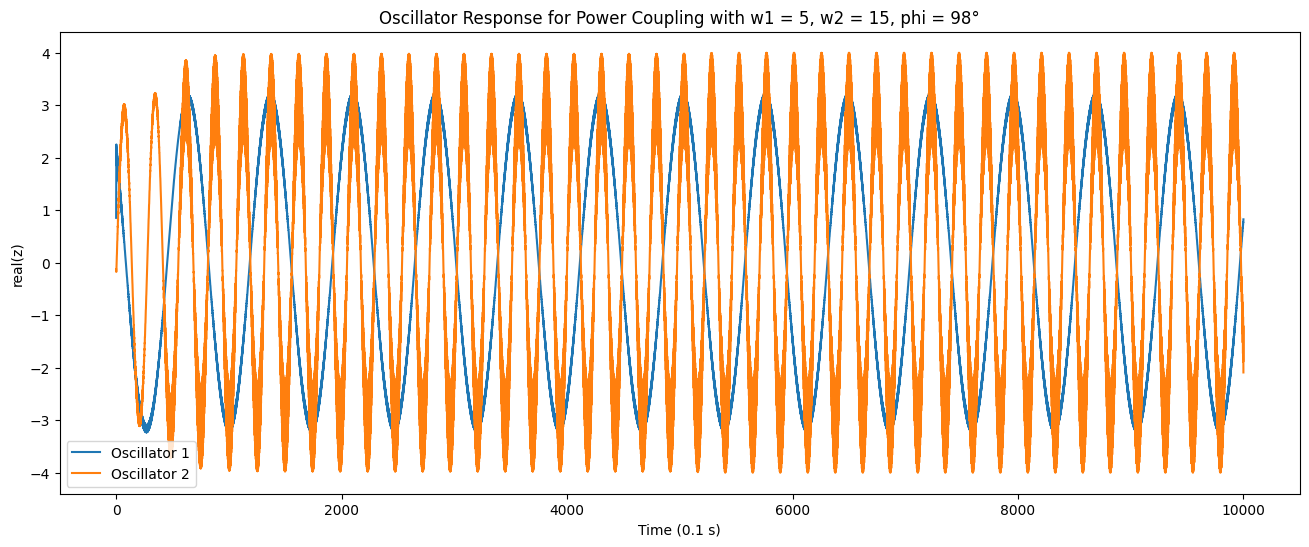

In [13]:
response_plotter(w1, w2, phi2, 'Power')

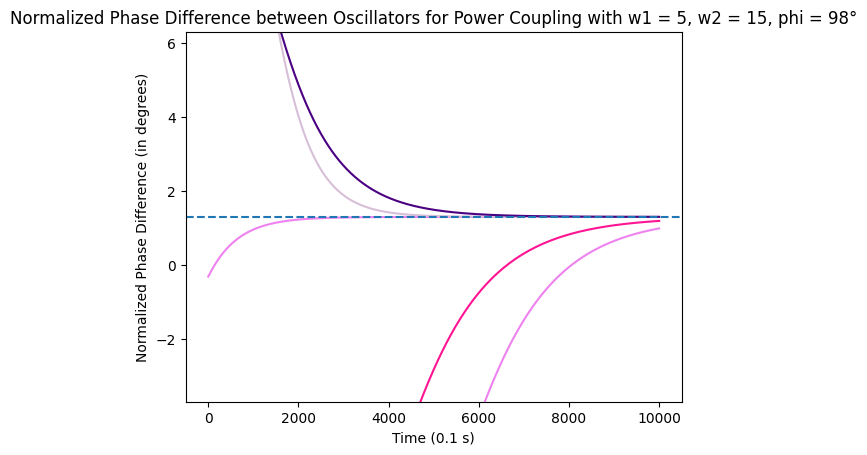

<Figure size 1000x600 with 0 Axes>

In [14]:
phase_diff_plotter(w1, w2, phi2, 'Power')